# DEL ACERO AL ALGORITMO
## Estadística Descriptiva aplicada a la Educación Superior del Biobío

**Base de datos:** Matrículas de Educación Superior de la Región del Biobío, 2021.

### Pregunta central del trabajo
**¿Qué peso tenía en 2021 la formación ligada a los motores productivos del Biobío frente a las capacidades que pueden transformarlos mediante digitalización, automatización y sustentabilidad?**

Este notebook se desarrolla siguiendo el mismo recorrido trabajado en los laboratorios del curso:

0. Introducción a Pandas.
1. Población, muestra y clasificación de variables.
2. Tablas de frecuencia.
3. Gráficos.
4. Medidas de tendencia central y percentiles.
5. Medidas de dispersión.
6. Aplicación regional “Del acero al algoritmo”.
7. Preguntas obligatorias del trabajo.

> **Criterio de trabajo:** primero se calcula, después se observa el resultado y finalmente se interpreta. Las conclusiones son descriptivas y no causales.


# 0. Introducción a Pandas

Antes de comenzar el análisis estadístico revisaremos la base usando las herramientas básicas de Pandas trabajadas en el Laboratorio 0.


### 0.1 Importar Pandas y cargar la base de datos


In [1]:
#Primero importamos la biblioteca Pandas que nos permitirá trabajar con DataFrames
import pandas as pd

#Creamos el DataFrame con la base de datos
df = pd.read_excel(
    '11_MATRICULAS_ED_SUPERIOR_BIOBIO_2021.xlsx',
    sheet_name='BASE DE DATOS'
)


### 0.2 Mostrar las primeras y últimas filas


In [2]:
#Primeras 5 filas del DataFrame
df.head(5)


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,AÑOS DE ACREDITACION,NOMBRE CARRERA,REQUISITO INGRESO,VIA DE INGRESO,MODALIDAD,JORNADA,TIPO PLAN CARRERA,NIVEL DE ESTUDIO CARRERA,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,52,Femenino,24,20 a 24,2016,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE CONCEPCION,ACREDITADA,11/11/2016 AL 11/11/2023,7.0,NUTRICION Y DIETETICA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Salud,10,0,10,120000,4243207,Biobio,Concepcion,Concepcion
1,58,Masculino,49,40 y mas,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,5.0,TECNICO EN AUTOMATIZACION Y CONTROL INDUSTRIAL,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Tecnologia,5,1,5,190000,1840000,Biobio,Concepcion,Concepcion
2,73,Masculino,21,20 a 24,2021,Primer semestre,Universidades Privadas,UNIVERSIDAD DEL DESARROLLO,ACREDITADA,15/12/2016 AL 15/12/2021,5.0,DERECHO,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Derecho,10,2,12,494445,5351640,Biobio,Concepcion,Concepcion
3,80,Femenino,24,20 a 24,2020,Primer semestre,Centros de Formacion Tecnica,CFT LOTA-ARAUCO,ACREDITADA,21/07/2019 AL 21/07/2023,4.0,CONSTRUCCION,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Tecnologia,5,1,5,30000,1450000,Biobio,Concepcion,Lota
4,88,Femenino,25,25 a 29,2018,Primer semestre,Universidades CRUCH,UNIVERSIDAD DEL BIO-BIO,ACREDITADA,28/08/2019 AL 28/08/2024,5.0,INGENIERIA COMERCIAL,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Administracion y Comercio,10,0,10,105000,3255000,Biobio,Concepcion,Concepcion


In [3]:
#Últimas 5 filas del DataFrame
df.tail(5)


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,AÑOS DE ACREDITACION,NOMBRE CARRERA,REQUISITO INGRESO,VIA DE INGRESO,MODALIDAD,JORNADA,TIPO PLAN CARRERA,NIVEL DE ESTUDIO CARRERA,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
106550,1048434,Masculino,29,25 a 29,2011,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE CONCEPCION,ACREDITADA,11/11/2016 AL 11/11/2023,7.0,OBSTETRICIA Y PUERICULTURA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Salud,10,0,10,120000,4243207,Biobio,Concepcion,Concepcion
106551,1048455,Masculino,26,25 a 29,2019,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,4.0,PSICOLOGIA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Ciencias Sociales,10,0,10,134000,3987000,Biobio,Concepcion,Concepcion
106552,1048467,Masculino,33,30 a 34,2020,Primer semestre,Institutos Profesionales,IP DUOC UC,ACREDITADA,26/08/2017 AL 26/08/2024,7.0,INGENIERIA EN CONSTRUCCION,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Profesionales,Tecnologia,8,1,8,216000,2150000,Biobio,Concepcion,Concepcion
106553,1048487,Femenino,21,20 a 24,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE CONCEPCION,ACREDITADA,11/11/2016 AL 11/11/2023,7.0,BIOLOGIA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Ciencias Basicas,10,0,10,120000,4144870,Biobio,Concepcion,Concepcion
106554,1048513,Femenino,29,25 a 29,2020,Primer semestre,Universidades CRUCH,UNIVERSIDAD CATOLICA DE LA SANTISIMA CONCEPCION,ACREDITADA,03/03/2021 AL 03/03/2026,5.0,PEDAGOGIA EN EDUCACION MEDIA EN MATEMATICA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Educacion,9,1,9,90000,2187000,Biobio,Concepcion,Concepcion


### 0.3 Conocer la dimensión y el tipo del objeto


In [4]:
#Para conocer la dimensión del DataFrame usamos shape
df.shape


(106555, 28)

In [5]:
#Verificamos el tipo de objeto
type(df)


pandas.core.frame.DataFrame

### 0.4 Revisar la información de las columnas


In [6]:
#La función info() permite revisar nombres de columnas, datos no nulos y tipos de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106555 entries, 0 to 106554
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   ID                                       106555 non-null  int64  
 1   GENERO                                   106555 non-null  object 
 2   EDAD                                     106555 non-null  int64  
 3   RANGO EDAD                               106555 non-null  object 
 4   AÑO INGRESO                              106555 non-null  int64  
 5   SEMESTRE INGRESO                         106555 non-null  object 
 6   TIPO DE INSTITUCION                      106555 non-null  object 
 7   NOMBRE DE INSTITUCION                    106555 non-null  object 
 8   ACREDITACION INSTITUCIONAL               106555 non-null  object 
 9   PERIODO DE ACREDITACION                  102840 non-null  object 
 10  AÑOS DE ACREDITACION            

La base original contiene **106.555 filas y 28 columnas**.

La revisión con `info()` permite comprobar cómo fueron importadas las variables. Para las variables que utilizaremos en el análisis no es necesario realizar una conversión de tipo con `astype()`.


### 0.5 Seleccionar columnas de interés


In [7]:
#Mostramos solamente algunas columnas que serán importantes en el análisis
df[
    ['GENERO', 'EDAD', 'TIPO DE INSTITUCION', 'NOMBRE CARRERA',
     'AREA CONOCIMIENTO', 'VALOR ARANCEL (PESOS)', 'PROVINCIA SEDE']
].head(5)


,GENERO,EDAD,TIPO DE INSTITUCION,NOMBRE CARRERA,AREA CONOCIMIENTO,VALOR ARANCEL (PESOS),PROVINCIA SEDE
0,Femenino,24,Universidades CRUCH,NUTRICION Y DIETETICA,Salud,4243207,Concepcion
1,Masculino,49,Institutos Profesionales,TECNICO EN AUTOMATIZACION Y CONTROL INDUSTRIAL,Tecnologia,1840000,Concepcion
2,Masculino,21,Universidades Privadas,DERECHO,Derecho,5351640,Concepcion
3,Femenino,24,Centros de Formacion Tecnica,CONSTRUCCION,Tecnologia,1450000,Concepcion
4,Femenino,25,Universidades CRUCH,INGENIERIA COMERCIAL,Administracion y Comercio,3255000,Concepcion


### 0.6 Contar valores con value_counts()


In [8]:
#Contamos cuántas veces aparece cada nivel de carrera
df['NIVEL CARRERA'].value_counts()


NIVEL CARRERA
Carreras Profesionales    75855
Carreras Tecnicas         25238
Magister                   3340
Postitulo                  1710
Doctorado                   412
Name: count, dtype: int64

La mayor parte de la base corresponde a **Carreras Profesionales** y **Carreras Técnicas**. Para comparar estudiantes de un mismo nivel formativo, el análisis principal se concentrará en estas dos categorías de pregrado.


### 0.7 Filtrar la base y crear una nueva columna


In [9]:
#Definimos los niveles de pregrado que utilizaremos
pregrado = ['Carreras Profesionales', 'Carreras Tecnicas']

#Filtramos las matrículas de pregrado
d = df[df['NIVEL CARRERA'].isin(pregrado)].copy()

#Para estudiar precios usamos pregrado y aranceles mayores que $0
d_precio = df[
    (df['NIVEL CARRERA'].isin(pregrado)) &
    (df['VALOR ARANCEL (PESOS)'] > 0)
].copy()

#Agregamos una nueva columna expresando el arancel en millones de pesos
d_precio['ARANCEL_MILLONES'] = (
    d_precio['VALOR ARANCEL (PESOS)'] / 1000000
)

print(f'Matrículas de pregrado: {d.shape[0]}')
print(f'Matrículas de pregrado con arancel mayor que $0: {d_precio.shape[0]}')


Matrículas de pregrado: 101093
Matrículas de pregrado con arancel mayor que $0: 101067


La base de pregrado contiene **101.093 matrículas**. Para los análisis que utilizan precio se consideran **101.067 registros**, porque existen **26 matrículas de pregrado con arancel registrado en $0**.

El valor $0 se excluye solamente de los análisis de precio. No se interpreta como gratuidad, porque la base no entrega esa explicación.


## Oferta académica única

Cuando analizamos aranceles debemos evitar contar el mismo precio una vez por cada estudiante matriculado. Por eso construiremos una base de **ofertas académicas únicas**.


In [10]:
#Columnas que identifican una oferta académica
clave_oferta = [
    'NOMBRE DE INSTITUCION',
    'NOMBRE CARRERA',
    'COMUNA SEDE',
    'MODALIDAD',
    'JORNADA',
    'DURACION TOTAL CARRERA (SEMESTRES)',
    'VALOR MATRICULA (PESOS)',
    'VALOR ARANCEL (PESOS)'
]

#Eliminamos ofertas repetidas
ofertas = d_precio.drop_duplicates(subset=clave_oferta).copy()

#Cantidad de ofertas únicas
ofertas.shape[0]


1273

Se obtienen **1.273 ofertas académicas únicas**.

- `d` se utilizará cuando la pregunta se refiera a **matrículas o estudiantes**.
- `d_precio` se utilizará para describir el **arancel asociado a las matrículas**.
- `ofertas` se utilizará cuando comparemos el **precio de las ofertas académicas**.


# 1. Población, muestra y clasificación de variables

## 1.1 Población y muestra

**Población:** matrículas de educación superior de la Región del Biobío durante 2021.

**Muestra o base disponible:** 106.555 registros entregados en la base de datos.

Para el análisis principal se trabaja además con una subbase de **101.093 matrículas de pregrado**.


## 1.2 Clasificación de las variables

La clasificación es importante porque determina qué tablas, gráficos y medidas estadísticas son adecuadas.


| Variable | Clasificación |
|---|---|
| ID | Cualitativa nominal (identificador) |
| GENERO | Cualitativa nominal |
| EDAD | Cuantitativa continua |
| RANGO EDAD | Cualitativa ordinal |
| AÑO INGRESO | Cuantitativa discreta |
| SEMESTRE INGRESO | Cualitativa ordinal |
| TIPO DE INSTITUCION | Cualitativa nominal |
| NOMBRE DE INSTITUCION | Cualitativa nominal |
| ACREDITACION INSTITUCIONAL | Cualitativa nominal |
| PERIODO DE ACREDITACION | Cualitativa nominal |
| AÑOS DE ACREDITACION | Cuantitativa discreta |
| NOMBRE CARRERA | Cualitativa nominal |
| REQUISITO INGRESO | Cualitativa nominal |
| VIA DE INGRESO | Cualitativa nominal |
| MODALIDAD | Cualitativa nominal |
| JORNADA | Cualitativa nominal |
| TIPO PLAN CARRERA | Cualitativa nominal |
| NIVEL DE ESTUDIO CARRERA | Cualitativa nominal |
| NIVEL CARRERA | Cualitativa nominal |
| AREA CONOCIMIENTO | Cualitativa nominal |
| DURACION PLAN DE ESTUDIO (SEMESTRES) | Cuantitativa discreta |
| DURACION PROCESO TITULACION (SEMESTRES) | Cuantitativa discreta |
| DURACION TOTAL CARRERA (SEMESTRES) | Cuantitativa discreta |
| VALOR MATRICULA (PESOS) | Cuantitativa continua |
| VALOR ARANCEL (PESOS) | Cuantitativa continua |
| REGION SEDE | Cualitativa nominal |
| PROVINCIA SEDE | Cualitativa nominal |
| COMUNA SEDE | Cualitativa nominal |


# 2. Tablas de frecuencias

Aplicaremos las tablas trabajadas en el Laboratorio 2. Para variables nominales usaremos frecuencia absoluta y relativa. Para variables cuantitativas ordenadas o agrupadas en intervalos agregaremos las frecuencias acumuladas.


## 2.1 Variable cualitativa nominal: género


In [11]:
#Valores distintos presentes en la variable
d['GENERO'].unique()


array(['Femenino', 'Masculino'], dtype=object)

In [12]:
#Frecuencia absoluta
cuenta_genero = d.groupby('GENERO').size()

#Tabla de frecuencias
tabla_genero = pd.DataFrame({
    'Frecuencia absoluta': cuenta_genero,
    'Frecuencia relativa (%)': round(cuenta_genero/d.shape[0] * 100, 1)
})

tabla_genero


,Frecuencia absoluta,Frecuencia relativa (%)
GENERO,,
Femenino,54881,54.3
Masculino,46212,45.7


**Interpretación:** las matrículas femeninas representan aproximadamente **54,3%** y las masculinas **45,7%** de la base de pregrado.


## 2.2 Variable cualitativa nominal: área del conocimiento


In [13]:
#Valores distintos de la variable
d['AREA CONOCIMIENTO'].unique()


array(['Salud', 'Tecnologia', 'Derecho', 'Administracion y Comercio',
       'Ciencias Basicas', 'Ciencias Sociales', 'Educacion',
       'Arte y Arquitectura', 'Agropecuaria', 'Humanidades'], dtype=object)

In [14]:
#Frecuencia absoluta
cuenta_area = d.groupby('AREA CONOCIMIENTO').size()

#Tabla de frecuencias absolutas y relativas
tabla_area = pd.DataFrame({
    'Frecuencia absoluta': cuenta_area,
    'Frecuencia relativa (%)': round(cuenta_area/d.shape[0] * 100, 1)
})

#Ordenamos de mayor a menor frecuencia
tabla_area = tabla_area.sort_values(
    'Frecuencia absoluta',
    ascending=False
)

tabla_area


,Frecuencia absoluta,Frecuencia relativa (%)
AREA CONOCIMIENTO,,
Tecnologia,27866,27.6
Salud,24597,24.3
Administracion y Comercio,13526,13.4
Educacion,11480,11.4
Ciencias Sociales,10677,10.6
Arte y Arquitectura,3611,3.6
Derecho,3529,3.5
Ciencias Basicas,2936,2.9
Agropecuaria,2361,2.3


**Interpretación:** Tecnología es el área con mayor frecuencia, seguida por Salud. Al tratarse de una variable cualitativa nominal, **no corresponde calcular frecuencias acumuladas**.


## 2.3 Variable cuantitativa discreta: duración total de la carrera


In [15]:
#Frecuencia absoluta
cuenta_duracion = d.groupby(
    'DURACION TOTAL CARRERA (SEMESTRES)'
).size()

#Tabla con las cuatro frecuencias
tabla_duracion = pd.DataFrame({
    'Frecuencia absoluta': cuenta_duracion,
    'Frecuencia absoluta acumulada': cuenta_duracion.cumsum(),
    'Frecuencia relativa (%)': cuenta_duracion/d.shape[0] * 100,
    'Frecuencia relativa acumulada (%)': (
        cuenta_duracion/d.shape[0] * 100
    ).cumsum()
})

round(tabla_duracion, 1)


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
DURACION TOTAL CARRERA (SEMESTRES),,,,
2,216,216,0.2,0.2
3,354,570,0.4,0.6
4,8294,8864,8.2,8.8
5,20766,29630,20.5,29.3
6,1100,30730,1.1,30.4
7,368,31098,0.4,30.8
8,15056,46154,14.9,45.7
9,3256,49410,3.2,48.9
10,34932,84342,34.6,83.4


**Interpretación:** la duración más frecuente es de **10 semestres**. Al ser una variable cuantitativa ordenada, las frecuencias acumuladas sí tienen sentido.


## 2.4 Variable cuantitativa agrupada: edad


In [16]:
#Creamos una nueva columna con intervalos de edad
d['Intervalos_edad'] = pd.cut(
    d['EDAD'],
    bins=10,
    include_lowest=True,
    precision=0
)

#Frecuencia absoluta de los intervalos
cuenta_edad = d.groupby(
    'Intervalos_edad',
    observed=True
).size()

#Tabla con las cuatro frecuencias
tabla_edad = pd.DataFrame({
    'Frecuencia absoluta': cuenta_edad,
    'Frecuencia absoluta acumulada': cuenta_edad.cumsum(),
    'Frecuencia relativa (%)': cuenta_edad/d.shape[0] * 100,
    'Frecuencia relativa acumulada (%)': (
        cuenta_edad/d.shape[0] * 100
    ).cumsum()
})

round(tabla_edad, 1)


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_edad,,,,
"(16.0, 23.0]",48400,48400,47.9,47.9
"(23.0, 29.0]",35920,84320,35.5,83.4
"(29.0, 35.0]",9489,93809,9.4,92.8
"(35.0, 41.0]",3706,97515,3.7,96.5
"(41.0, 46.0]",2061,99576,2.0,98.5
"(46.0, 52.0]",1072,100648,1.1,99.6
"(52.0, 58.0]",362,101010,0.4,99.9
"(58.0, 64.0]",73,101083,0.1,100.0
"(64.0, 70.0]",7,101090,0.0,100.0


**Interpretación:** la mayor parte de las matrículas se concentra en los intervalos de menor edad. La frecuencia acumulada permite observar qué porcentaje de estudiantes se encuentra hasta cada intervalo.


## 2.5 Variable cuantitativa agrupada: arancel


In [17]:
#Creamos una nueva columna con intervalos de arancel
d_precio['Intervalos_arancel'] = pd.cut(
    d_precio['VALOR ARANCEL (PESOS)'],
    bins=9,
    include_lowest=True,
    precision=0
)

#Frecuencia absoluta
cuenta_arancel = d_precio.groupby(
    'Intervalos_arancel',
    observed=True
).size()

#Tabla con las cuatro frecuencias
tabla_arancel = pd.DataFrame({
    'Frecuencia absoluta': cuenta_arancel,
    'Frecuencia absoluta acumulada': cuenta_arancel.cumsum(),
    'Frecuencia relativa (%)': cuenta_arancel/d_precio.shape[0] * 100,
    'Frecuencia relativa acumulada (%)': (
        cuenta_arancel/d_precio.shape[0] * 100
    ).cumsum()
})

round(tabla_arancel, 1)


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_arancel,,,,
"(641865.0, 1553741.0]",10846,10846,10.7,10.7
"(1553741.0, 2457482.0]",32641,43487,32.3,43.0
"(2457482.0, 3361223.0]",11719,55206,11.6,54.6
"(3361223.0, 4264964.0]",20615,75821,20.4,75.0
"(4264964.0, 5168706.0]",17271,93092,17.1,92.1
"(5168706.0, 6072447.0]",4193,97285,4.1,96.3
"(6072447.0, 6976188.0]",1462,98747,1.4,97.7
"(6976188.0, 7879929.0]",1257,100004,1.2,98.9
"(7879929.0, 8783670.0]",1063,101067,1.1,100.0


**Interpretación:** el arancel no se distribuye de manera uniforme. La mayor cantidad de matrículas se concentra en los tramos intermedios, mientras que los valores muy altos aparecen con menor frecuencia.


# 3. Gráficos

Ahora representaremos las variables con los tipos de gráficos trabajados en el Laboratorio 3.


In [18]:
#Biblioteca para graficar
import matplotlib.pyplot as plt


## 3.1 Gráfico circular y gráfico de barras: género


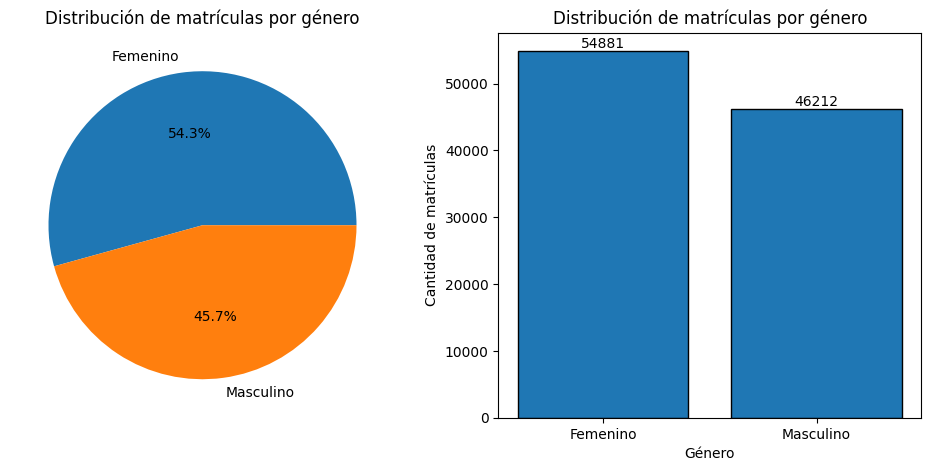

In [19]:
#Variables
categorias_genero = tabla_genero.index
h_genero = tabla_genero['Frecuencia relativa (%)']
f_genero = tabla_genero['Frecuencia absoluta']

#Creamos una figura con dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

#Gráfico circular
ax1.pie(
    h_genero,
    labels=categorias_genero,
    autopct='%.1f%%'
)

#Gráfico de barras
barras_genero = ax2.bar(
    categorias_genero,
    f_genero,
    edgecolor='black'
)

#Personalización
ax1.set_title('Distribución de matrículas por género')
ax2.set_title('Distribución de matrículas por género')
ax2.set_xlabel('Género')
ax2.set_ylabel('Cantidad de matrículas')
ax2.bar_label(barras_genero)

plt.show()


## 3.2 Gráfico de barras: área del conocimiento


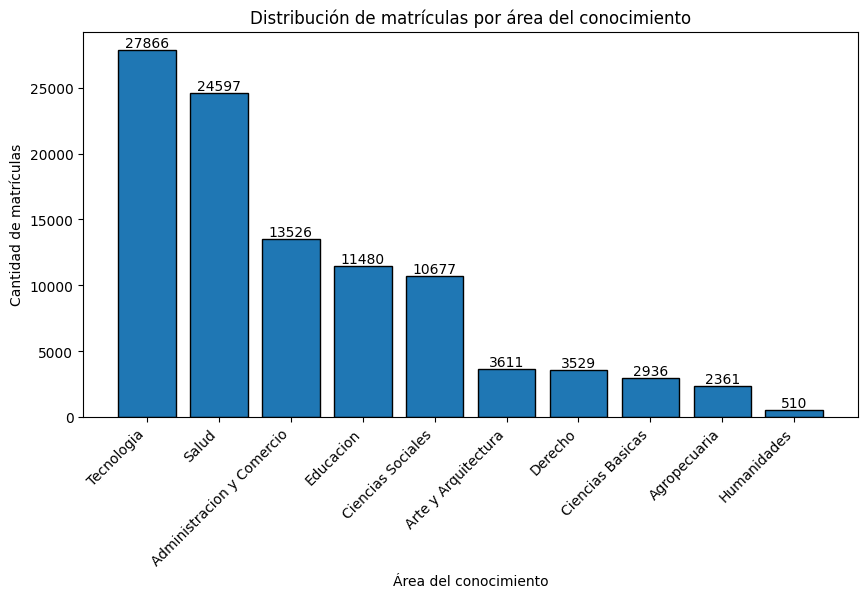

In [20]:
#Variables
categorias_area = tabla_area.index
f_area = tabla_area['Frecuencia absoluta']

#Gráfico
fig, ax = plt.subplots(figsize=(10,5))
barras_area = ax.bar(
    categorias_area,
    f_area,
    edgecolor='black'
)

#Personalización
ax.set_title('Distribución de matrículas por área del conocimiento')
ax.set_xlabel('Área del conocimiento')
ax.set_ylabel('Cantidad de matrículas')
ax.bar_label(barras_area)
plt.xticks(rotation=45, ha='right')

plt.show()


## 3.3 Histograma construido con intervalos: edad


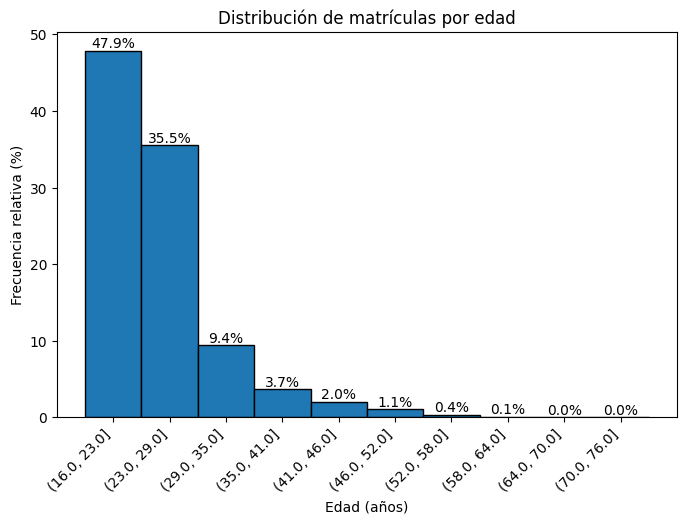

In [21]:
#Variables
categorias_edad = tabla_edad.index
h_edad = tabla_edad['Frecuencia relativa (%)']

#Gráfico
fig, ax = plt.subplots(figsize=(8,5))
histograma_edad = ax.bar(
    categorias_edad.astype(str),
    h_edad,
    edgecolor='black',
    width=1
)

#Personalización
ax.set_title('Distribución de matrículas por edad')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia relativa (%)')
ax.bar_label(histograma_edad, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')

plt.show()


## 3.4 Histograma construido con intervalos: arancel


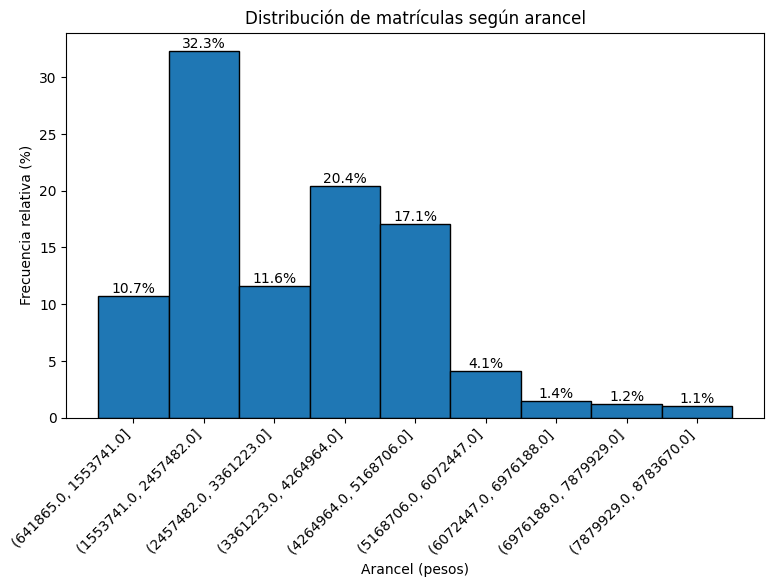

In [22]:
#Variables
categorias_arancel = tabla_arancel.index
h_arancel = tabla_arancel['Frecuencia relativa (%)']

#Gráfico
fig, ax = plt.subplots(figsize=(9,5))
histograma_arancel = ax.bar(
    categorias_arancel.astype(str),
    h_arancel,
    edgecolor='black',
    width=1
)

#Personalización
ax.set_title('Distribución de matrículas según arancel')
ax.set_xlabel('Arancel (pesos)')
ax.set_ylabel('Frecuencia relativa (%)')
ax.bar_label(histograma_arancel, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')

plt.show()


## 3.5 Las 10 carreras con mayor cantidad de matrículas


In [23]:
#Frecuencia absoluta por carrera
cuenta_carrera = d.groupby('NOMBRE CARRERA').size()

#Creamos la tabla y ordenamos de mayor a menor
tabla_top10 = pd.DataFrame({
    'Frecuencia absoluta': cuenta_carrera
})

tabla_top10 = tabla_top10.sort_values(
    'Frecuencia absoluta',
    ascending=False
).head(10)

tabla_top10


,Frecuencia absoluta
NOMBRE CARRERA,
ENFERMERIA,4226
PSICOLOGIA,3181
INGENIERIA COMERCIAL,2868
DERECHO,2854
INGENIERIA CIVIL INDUSTRIAL,2851
TRABAJO SOCIAL,2390
TECNICO EN ENFERMERIA,2371
KINESIOLOGIA,1932
ODONTOLOGIA,1901


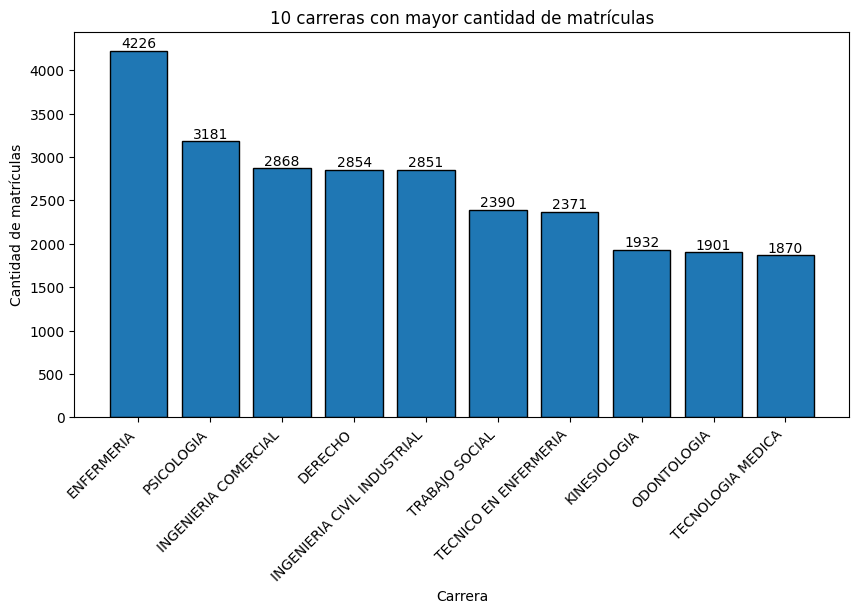

In [24]:
#Variables
categorias_carrera = tabla_top10.index
f_carrera = tabla_top10['Frecuencia absoluta']

#Gráfico
fig, ax = plt.subplots(figsize=(10,5))
barras_carrera = ax.bar(
    categorias_carrera,
    f_carrera,
    edgecolor='black'
)

#Personalización
ax.set_title('10 carreras con mayor cantidad de matrículas')
ax.set_xlabel('Carrera')
ax.set_ylabel('Cantidad de matrículas')
ax.bar_label(barras_carrera)
plt.xticks(rotation=45, ha='right')

plt.show()


## 3.6 Gráfico de dispersión: edad y arancel


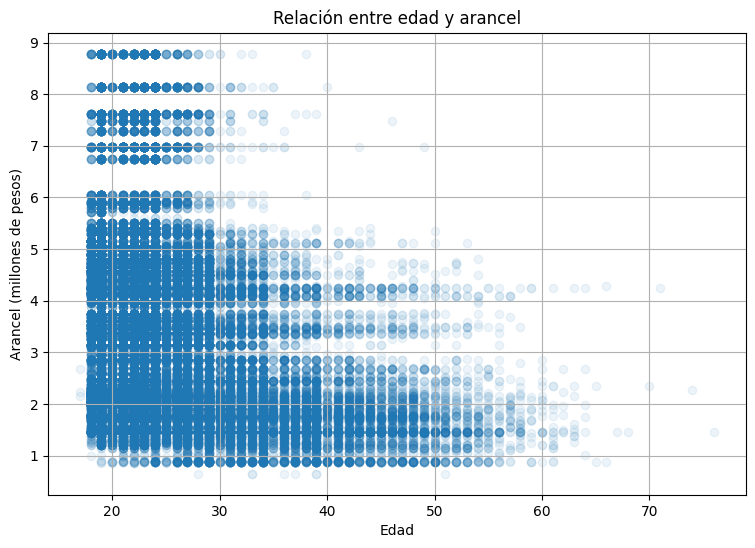

In [25]:
#Gráfico de dispersión
plt.figure(figsize=(9,6))

plt.scatter(
    d_precio['EDAD'],
    d_precio['ARANCEL_MILLONES'],
    alpha=0.08
)

plt.title('Relación entre edad y arancel')
plt.xlabel('Edad')
plt.ylabel('Arancel (millones de pesos)')
plt.grid(True)

plt.show()


**Interpretación:** visualmente no se observa una relación lineal simple entre edad y arancel. Para edades similares aparecen aranceles muy distintos, por lo que no corresponde concluir que una mayor edad implique un arancel más alto.


# 4. Medidas de Tendencia Central y Percentiles

Aplicaremos media, mediana, moda, percentiles, `describe()` y análisis agrupados como en el Laboratorio 4.


## 4.1 Media, mediana y moda del arancel


In [26]:
#Media, mediana y moda del arancel asociado a las matrículas
media_arancel = d_precio['VALOR ARANCEL (PESOS)'].mean()
mediana_arancel = d_precio['VALOR ARANCEL (PESOS)'].median()
moda_arancel = d_precio['VALOR ARANCEL (PESOS)'].mode()

print(f'Media: ${media_arancel:.0f}')
print(f'Mediana: ${mediana_arancel}')
print(f'Moda: ${moda_arancel[0]}')


Media: $3224895
Mediana: $3133750.0
Moda: $3373000


**Interpretación:** la media del arancel es aproximadamente **$3.224.895**, la mediana **$3.133.750** y la moda **$3.373.000**.

La media es un poco mayor que la mediana, lo que indica que los aranceles altos elevan el promedio.


## 4.2 Media, mediana y moda de la edad


In [27]:
#Media, mediana y moda de la edad
media_edad = d['EDAD'].mean()
mediana_edad = d['EDAD'].median()
moda_edad = d['EDAD'].mode()

print(f'Media: {media_edad:.1f} años')
print(f'Mediana: {mediana_edad} años')
print(f'Moda: {moda_edad[0]} años')


Media: 24.4 años
Mediana: 23.0 años
Moda: 19 años


**Interpretación:** la edad promedio es aproximadamente **24,4 años**, la mediana **23 años** y la moda **19 años**.


## 4.3 Percentiles


In [28]:
#Percentiles del arancel
p25_arancel = d_precio['VALOR ARANCEL (PESOS)'].quantile(0.25)
p50_arancel = d_precio['VALOR ARANCEL (PESOS)'].quantile(0.50)
p75_arancel = d_precio['VALOR ARANCEL (PESOS)'].quantile(0.75)
p90_arancel = d_precio['VALOR ARANCEL (PESOS)'].quantile(0.90)

print(f'Percentil 25: ${p25_arancel}')
print(f'Percentil 50: ${p50_arancel}')
print(f'Percentil 75: ${p75_arancel}')
print(f'Percentil 90: ${p90_arancel}')


Percentil 25: $1988000.0
Percentil 50: $3133750.0
Percentil 75: $4261900.0
Percentil 90: $5010660.000000405


In [29]:
#Percentiles de la edad
p25_edad = d['EDAD'].quantile(0.25)
p50_edad = d['EDAD'].quantile(0.50)
p75_edad = d['EDAD'].quantile(0.75)
p90_edad = d['EDAD'].quantile(0.90)

print(f'Percentil 25: {p25_edad} años')
print(f'Percentil 50: {p50_edad} años')
print(f'Percentil 75: {p75_edad} años')
print(f'Percentil 90: {p90_edad} años')


Percentil 25: 21.0 años
Percentil 50: 23.0 años
Percentil 75: 26.0 años
Percentil 90: 32.0 años


**Interpretación de los percentiles:**

- El **25%** de las matrículas con arancel informado registra un arancel igual o inferior a **$1.988.000**.
- El **50%** registra un arancel igual o inferior a **$3.133.750**.
- El **75%** registra un arancel igual o inferior a **$4.261.900**.
- El **90%** registra un arancel igual o inferior a **$5.010.660**.

En edad, el percentil 50 indica que el 50% de las matrículas corresponde a estudiantes de **23 años o menos**.


## 4.4 Resumen descriptivo con describe()


In [30]:
#Resumen de variables cuantitativas
d[
    ['EDAD',
     'DURACION TOTAL CARRERA (SEMESTRES)']
].describe().astype(int)


,EDAD,DURACION TOTAL CARRERA (SEMESTRES)
count,101093,101093
mean,24,8
std,6,2
min,17,2
25%,21,5
50%,23,10
75%,26,10
max,76,14


In [31]:
#Resumen del arancel usando solamente registros con arancel mayor que $0
d_precio[
    ['VALOR ARANCEL (PESOS)']
].describe().astype(int)


,VALOR ARANCEL (PESOS)
count,101067
mean,3224894
std,1518990
min,650000
25%,1988000
50%,3133750
75%,4261900
max,8783670


## 4.5 Moda de una variable cualitativa


In [32]:
#Área del conocimiento que aparece con mayor frecuencia
moda_area = d['AREA CONOCIMIENTO'].mode()
moda_area[0]


'Tecnologia'

El área del conocimiento que aparece con mayor frecuencia es **Tecnología**.


## 4.6 Medidas agrupadas por área del conocimiento


In [33]:
#Agrupamos las ofertas por área
datos_area = ofertas.groupby(
    'AREA CONOCIMIENTO'
)['VALOR ARANCEL (PESOS)']

#Calculamos las medidas solicitadas
media_area = datos_area.mean()
mediana_area = datos_area.median()
p25_area = datos_area.quantile(0.25)
p75_area = datos_area.quantile(0.75)

#Creamos un nuevo DataFrame
tabla_medidas_area = pd.DataFrame({
    'Media': media_area,
    'Mediana': mediana_area,
    'Percentil 25': p25_area,
    'Percentil 75': p75_area
})

round(tabla_medidas_area, 0)


,Media,Mediana,Percentil 25,Percentil 75
AREA CONOCIMIENTO,,,,
Administracion y Comercio,2031019.0,1855000.0,1537000.0,2122000.0
Agropecuaria,3150941.0,2981500.0,1824250.0,4335000.0
Arte y Arquitectura,2452345.0,1940000.0,1786000.0,2826500.0
Ciencias Basicas,3256166.0,3290000.0,2194500.0,4278045.0
Ciencias Sociales,2129750.0,1675500.0,1380000.0,2616000.0
Derecho,3319065.0,3586000.0,2350000.0,4215000.0
Educacion,1952592.0,1722500.0,1399000.0,2654850.0
Humanidades,2115167.0,2006500.0,1717500.0,2579904.0
Salud,3044197.0,2080000.0,1781000.0,4203000.0


Esta tabla permite comparar el centro y los percentiles del arancel entre áreas sin limitarse a un único promedio.


## 4.7 Tabla bivariada con crosstab()


In [34]:
#Media del arancel según área y tipo de institución
tabla_bivariada = pd.crosstab(
    ofertas['AREA CONOCIMIENTO'],
    ofertas['TIPO DE INSTITUCION'],
    ofertas['VALOR ARANCEL (PESOS)'],
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)

round(tabla_bivariada, 0)


TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas,Total
AREA CONOCIMIENTO,,,,,,
Administracion y Comercio,1781338.0,1741044.0,NaN,2473294.0,2962050.0,2031019.0
Agropecuaria,1679333.0,1880000.0,NaN,4059110.0,4340417.0,3150941.0
Arte y Arquitectura,1769000.0,1850750.0,NaN,3848769.0,4637620.0,2452345.0
Ciencias Basicas,NaN,1878875.0,NaN,3758102.0,3495000.0,3256166.0
Ciencias Sociales,1353272.0,1419590.0,2327000.0,3691376.0,3069591.0,2129750.0
Derecho,NaN,1750000.0,2229000.0,4231569.0,3503926.0,3319065.0
Educacion,1364772.0,1439560.0,NaN,2673509.0,2490693.0,1952592.0
Humanidades,NaN,1005000.0,NaN,2763334.0,1929000.0,2115167.0
Salud,1735035.0,1740270.0,NaN,4419709.0,4246702.0,3044197.0


**Interpretación:** el arancel no cambia solamente entre áreas; también existen diferencias según el tipo de institución. La tabla bivariada permite observar ambas variables al mismo tiempo.


# 5. Medidas de Dispersión

Aplicaremos las tres medidas trabajadas en el Laboratorio 5:

- Rango.
- Desviación estándar.
- Coeficiente de variación.


## 5.1 Dispersión del arancel


In [35]:
#Calculamos el máximo y mínimo
maximo_arancel = d_precio['VALOR ARANCEL (PESOS)'].max()
minimo_arancel = d_precio['VALOR ARANCEL (PESOS)'].min()

#Calculamos el rango
rango_arancel = maximo_arancel - minimo_arancel

#Desviación estándar
desviacion_arancel = d_precio['VALOR ARANCEL (PESOS)'].std()

#Coeficiente de variación
cv_arancel = desviacion_arancel / media_arancel * 100

print(f'Rango: ${rango_arancel}')
print(f'Desviación estándar: ${desviacion_arancel:.0f}')
print(f'CV: {cv_arancel:.1f}%')


Rango: $8133670
Desviación estándar: $1518991
CV: 47.1%


El coeficiente de variación del arancel es aproximadamente **47,1%**. Esto muestra una dispersión importante respecto de su media.


## 5.2 Dispersión de la edad


In [36]:
#Máximo y mínimo
maximo_edad = d['EDAD'].max()
minimo_edad = d['EDAD'].min()

#Rango
rango_edad = maximo_edad - minimo_edad

#Desviación estándar
desviacion_edad = d['EDAD'].std()

#Coeficiente de variación
cv_edad = desviacion_edad / media_edad * 100

print(f'Rango: {rango_edad} años')
print(f'Desviación estándar: {desviacion_edad:.2f} años')
print(f'CV: {cv_edad:.1f}%')


Rango: 59 años
Desviación estándar: 6.24 años
CV: 25.6%


El coeficiente de variación de la edad es aproximadamente **25,6%**, menor que el del arancel. Por lo tanto, proporcionalmente, las edades son más homogéneas que los aranceles.


## 5.3 Comparación de dispersión entre grupos


In [37]:
#Obtenemos las cuatro áreas con mayor cantidad de matrículas
cuenta_area_disp = d.groupby('AREA CONOCIMIENTO').size()

tabla_area_disp = pd.DataFrame({
    'Frecuencia absoluta': cuenta_area_disp
})

tabla_area_disp = tabla_area_disp.sort_values(
    'Frecuencia absoluta',
    ascending=False
).head(4)

tabla_area_disp


,Frecuencia absoluta
AREA CONOCIMIENTO,
Tecnologia,27866
Salud,24597
Administracion y Comercio,13526
Educacion,11480


In [38]:
#Guardamos las cuatro áreas más frecuentes
areas_frecuentes = [
    'Tecnologia',
    'Salud',
    'Administracion y Comercio',
    'Educacion'
]

#Filtramos las ofertas de esas cuatro áreas
ofertas_top4 = ofertas[
    ofertas['AREA CONOCIMIENTO'].isin(areas_frecuentes)
]

#Agrupamos y calculamos media, mediana y desviación estándar
tabla_disp_area = ofertas_top4.groupby(
    'AREA CONOCIMIENTO'
)['VALOR ARANCEL (PESOS)'].agg(
    ['mean', 'median', 'std']
)

#Agregamos el coeficiente de variación
tabla_disp_area['CV (%)'] = (
    tabla_disp_area['std'] /
    tabla_disp_area['mean']
) * 100

round(tabla_disp_area, 1)


,mean,median,std,CV (%)
AREA CONOCIMIENTO,,,,
Administracion y Comercio,2031019.4,1855000.0,782572.5,38.5
Educacion,1952592.5,1722500.0,711373.3,36.4
Salud,3044197.1,2080000.0,1676000.9,55.1
Tecnologia,2301377.0,2122000.0,979998.2,42.6


**Interpretación:** entre las cuatro áreas con mayor matrícula, **Educación** presenta el menor coeficiente de variación en sus ofertas y, por lo tanto, aranceles relativamente más homogéneos. **Salud** presenta el mayor coeficiente de variación y, por tanto, mayor heterogeneidad relativa.


# 6. Aplicación regional — DEL ACERO AL ALGORITMO

Una vez aplicadas las herramientas estadísticas del curso, construiremos una clasificación propia para responder la pregunta regional del trabajo.

### Motores productivos
- Industria y manufactura.
- Construcción e infraestructura.
- Logística y puertos.
- Forestal y madera.
- Pesca y acuicultura.
- Agroalimentario.

### Capacidades transformadoras
- Digital y TIC.
- Automatización y robótica.
- Energía, sustentabilidad y biotecnología.

Las demás carreras se mantienen como **Otros campos**.

> Esta clasificación es una herramienta creada para este trabajo. No corresponde a una clasificación oficial.


## 6.1 Clasificación de las carreras

Para mantener el procedimiento similar al usado en los laboratorios, guardaremos las carreras en listas y utilizaremos `isin()` para filtrar y clasificar.


In [39]:
#Primero dejamos todas las carreras como "Otros campos"
d['ADN_BIOBIO'] = 'Otros campos'


In [40]:
#1. Industria y manufactura
industria = [
    "DISENO INDUSTRIAL",
    "ELECTRICIDAD INDUSTRIAL MENCION INSTALACIONES ELECTRICAS",
    "ELECTROMECANICA",
    "FABRICACION Y MONTAJE INDUSTRIAL",
    "INGENIERIA CIVIL DE MATERIALES",
    "INGENIERIA CIVIL EN METALURGIA",
    "INGENIERIA CIVIL INDUSTRIAL",
    "INGENIERIA CIVIL INDUSTRIAL - CONTINUIDAD INGENIEROS NO AFIN",
    "INGENIERIA CIVIL INDUSTRIAL, PROGRAMA CONTINUIDAD DE ESTUDIOS",
    "INGENIERIA CIVIL MECANICA",
    "INGENIERIA CIVIL METALURGICA",
    "INGENIERIA CIVIL QUIMICA",
    "INGENIERIA DE EJECUCION EN ELECTRICIDAD",
    "INGENIERIA DE EJECUCION EN ELECTRICIDAD-PE",
    "INGENIERIA DE EJECUCION EN GESTION INDUSTRIAL",
    "INGENIERIA DE EJECUCION EN MANTENIMIENTO INDUSTRIAL",
    "INGENIERIA DE EJECUCION EN MANTENIMIENTO INDUSTRIAL-PE",
    "INGENIERIA DE EJECUCION EN MECANICA",
    "INGENIERIA DE EJECUCION EN MECANICA AUTOMOTRIZ Y MAQUINARIA PESADA-PE",
    "INGENIERIA DE EJECUCION INDUSTRIAL",
    "INGENIERIA DE EJECUCION INDUSTRIAL PLAN CONTINUIDAD",
    "INGENIERIA DE EJECUCION INDUSTRIAL-PE",
    "INGENIERIA DE EJECUCION MECANICA",
    "INGENIERIA DE EJECUCION MECANICA DE PROCESOS Y MANTENIMIENTO INDUSTRIAL",
    "INGENIERIA DE EJECUCION MECANICA-PE",
    "INGENIERIA EN ELECTRICIDAD MENCION POTENCIA",
    "INGENIERIA EN ELECTRICIDAD MENCION PROYECTOS DE INSTALACIONES ELECTRICAS",
    "INGENIERIA EN MANTENIMIENTO INDUSTRIAL",
    "INGENIERIA EN MAQUINARIA PESADA Y VEHICULOS AUTOMOTRICES",
    "INGENIERIA EN MAQUINARIA, VEHICULOS AUTOMOTRICES Y SISTEMAS ELECTRONICOS",
    "INGENIERIA EN MECANICA AUTOMOTRIZ Y AUTOTRONICA",
    "INGENIERIA EN MECANICA Y ELECTROMOVILIDAD AUTOMOTRIZ",
    "INGENIERIA INDUSTRIAL",
    "INGENIERIA MECANICA EN MANTENIMIENTO INDUSTRIAL",
    "MANTENIMIENTO INDUSTRIAL",
    "MAQUINARIA PESADA",
    "MECANICA AUTOMOTRIZ EN MAQUINARIA PESADA",
    "MECANICA AUTOMOTRIZ EN SISTEMAS ELECTRONICOS",
    "MECANICA DE EQUIPO PESADO",
    "MECANICA INDUSTRIAL",
    "PROGRAMA DE CONTINUIDAD DE ESTUDIOS EN INGENIERIA DE EJECUCION INDUSTRIAL",
    "REFRIGERACION INDUSTRIAL Y AIRE ACONDICIONADO",
    "REFRIGERACION INDUSTRIAL Y CLIMATIZACION",
    "TECNICO DE NIVEL SUPERIOR EN MANTENCION INDUSTRIAL",
    "TECNICO DE NIVEL SUPERIOR EN MAQUINARIA NAVAL",
    "TECNICO EN ELECTRICIDAD",
    "TECNICO EN ELECTRICIDAD INDUSTRIAL",
    "TECNICO EN ELECTROMECANICA",
    "TECNICO EN FABRICACION Y MONTAJE INDUSTRIAL",
    "TECNICO EN MANTENIMIENTO INDUSTRIAL",
    "TECNICO EN MECANICA AUTOMOTRIZ Y AUTOTRONICA",
    "TECNICO EN MECANICA AUTOMOTRIZ Y MAQUINARIA PESADA",
    "TECNICO EN MECANICA AUTOMOTRIZ Y SISTEMAS ELECTRICOS",
    "TECNICO EN MECANICA Y ELECTROMOVILIDAD AUTOMOTRIZ",
    "TECNICO QUIMICO ANALISTA INDUSTRIAL",
    "TECNICO UNIVERSITARIO EN ELECTRICIDAD",
    "TECNICO UNIVERSITARIO EN MANTENIMIENTO INDUSTRIAL",
    "TECNICO UNIVERSITARIO EN MECANICA AUTOMOTRIZ",
    "TECNICO UNIVERSITARIO EN MECANICA INDUSTRIAL",
    "TECNICO UNIVERSITARIO EN QUIMICA CON MENCION EN QUIMICA INDUSTRIAL"
]

d.loc[
    d['NOMBRE CARRERA'].isin(industria),
    'ADN_BIOBIO'
] = 'Industria y manufactura'


In [41]:
#2. Construcción e infraestructura
construccion = [
    "ARQUITECTURA",
    "CONSTRUCCION",
    "CONSTRUCCION CIVIL",
    "CONSTRUCCION CIVIL (PLAN CONTINUIDAD)",
    "DIBUJO Y MODELAMIENTO ARQUITECTONICO Y ESTRUCTURAL",
    "INGENIERIA CIVIL",
    "INGENIERIA CIVIL-PLAN COMUN",
    "INGENIERIA EN CONSTRUCCION",
    "INGENIERIA EN CONSTRUCCION-PE",
    "PROGRAMA DE CONTINUIDAD DE ESTUDIOS EN CONSTRUCCION CIVIL",
    "TECNICO DE NIVEL SUPERIOR EN CONSTRUCCION",
    "TECNICO DE NIVEL SUPERIOR EN CONSTRUCCION CIVIL",
    "TECNICO EN CONSTRUCCION",
    "TECNICO EN CONSTRUCCIONES CIVILES",
    "TECNICO UNIVERSITARIO EN CONSTRUCCION"
]

d.loc[
    d['NOMBRE CARRERA'].isin(construccion),
    'ADN_BIOBIO'
] = 'Construccion e infraestructura'


In [42]:
#3. Logística y puertos
logistica = [
    "INGENIERIA CIVIL LOGISTICA",
    "INGENIERIA DE EJECUCION EN GESTION LOGISTICA-PE",
    "INGENIERIA DE EJECUCION EN LOGISTICA MARITIMA PORTUARIA",
    "INGENIERIA DE EJECUCION EN LOGISTICA MARITIMA PORTUARIA-PE",
    "INGENIERIA DE EJECUCION INDUSTRIAL MENCION MANTENIMIENTO Y LOGISTICA",
    "INGENIERIA EN COMERCIO EXTERIOR",
    "INGENIERIA EN GESTION LOGISTICA",
    "INGENIERIA EN LOGISTICA OPERATIVA",
    "INGENIERIA EN LOGISTICA Y TRANSPORTE",
    "LOGISTICA",
    "LOGISTICA Y OPERACIONES INDUSTRIALES",
    "TECNICO DE NIVEL SUPERIOR EN GESTION LOGISTICA",
    "TECNICO DE NIVEL SUPERIOR EN LOGISTICA Y OPERACIONES INDUSTRIALES",
    "TECNICO DE NIVEL SUPERIOR EN TRANSPORTE MARITIMO",
    "TECNICO EN ADMINISTRACION DE EMPRESAS MENCION LOGISTICA",
    "TECNICO EN COMERCIO EXTERIOR",
    "TECNICO EN GESTION LOGISTICA",
    "TECNICO EN LOGISTICA",
    "TECNICO EN LOGISTICA MARITIMA PORTUARIA",
    "TECNICO EN OPERACIONES LOGISTICAS",
    "TECNICO UNIVERSITARIO EN LOGISTICA"
]

d.loc[
    d['NOMBRE CARRERA'].isin(logistica),
    'ADN_BIOBIO'
] = 'Logistica y puertos'


In [43]:
#4. Forestal y madera
forestal = [
    "INGENIERIA CIVIL EN INDUSTRIAS DE LA MADERA",
    "INGENIERIA FORESTAL"
]

d.loc[
    d['NOMBRE CARRERA'].isin(forestal),
    'ADN_BIOBIO'
] = 'Forestal y madera'


In [44]:
#5. Pesca y acuicultura
pesca = [
    "ADMINISTRACION PORTUARIA PESQUERO ARTESANAL",
    "GESTION PORTUARIA Y PESQUERA",
    "INGENIERIA EN BIOTECNOLOGIA MARINA Y ACUICULTURA"
]

d.loc[
    d['NOMBRE CARRERA'].isin(pesca),
    'ADN_BIOBIO'
] = 'Pesca y acuicultura'


In [45]:
#6. Agroalimentario
agro = [
    "AGRONOMIA",
    "AGRONOMIA, PLAN CONTINUIDAD DE ESTUDIOS",
    "INGENIERIA AGRICOLA",
    "INGENIERIA DE EJECUCION AGROPECUARIA",
    "TECNICO AGRICOLA Y GANADERO",
    "TECNICO DE NIVEL SUPERIOR EN GESTION AGROINDUSTRIAL",
    "TECNICO EN VETERINARIA Y PRODUCCION PECUARIA",
    "TECNICO UNIVERSITARIO AGROPECUARIO",
    "TECNICO UNIVERSITARIO EN ALIMENTOS"
]

d.loc[
    d['NOMBRE CARRERA'].isin(agro),
    'ADN_BIOBIO'
] = 'Agroalimentario'


In [46]:
#7. Digital y TIC
digital = [
    "ANALISTA PROGRAMADOR",
    "ANALISTA PROGRAMADOR COMPUTACIONAL",
    "COMPUTACION E INFORMATICA",
    "INFORMATICA BIOMEDICA",
    "INGENIERIA CIVIL EN INFORMATICA",
    "INGENIERIA CIVIL EN TELECOMUNICACIONES",
    "INGENIERIA CIVIL INFORMATICA",
    "INGENIERIA DE EJECUCION EN COMPUTACION E INFORMATICA",
    "INGENIERIA DE EJECUCION EN COMPUTACION E INFORMATICA-PE",
    "INGENIERIA DE EJECUCION EN INFORMATICA MENCION DESARROLLO DE SISTEMAS",
    "INGENIERIA EN CIBERSEGURIDAD",
    "INGENIERIA EN CONECTIVIDAD Y REDES",
    "INGENIERIA EN INFORMATICA",
    "INGENIERIA EN TELECOMUNICACIONES, CONECTIVIDAD Y REDES",
    "INGENIERIA GEOMATICA",
    "INGENIERIA INFORMATICA",
    "PROGRAMACION COMPUTACIONAL",
    "PROGRAMACION Y ANALISIS DE SISTEMAS",
    "TECNICO ANALISTA PROGRAMADOR",
    "TECNICO EN CONECTIVIDAD Y REDES",
    "TECNICO EN PROGRAMACION Y ANALISIS DE SISTEMAS",
    "TECNICO UNIVERSITARIO EN INFORMATICA",
    "TECNICO UNIVERSITARIO EN TELECOMUNICACIONES Y REDES",
    "TELECOMUNICACIONES, CONECTIVIDAD Y REDES"
]

d.loc[
    d['NOMBRE CARRERA'].isin(digital),
    'ADN_BIOBIO'
] = 'Digital y TIC'


In [47]:
#8. Automatización y robótica
automatizacion = [
    "AUTOMATIZACION Y CONTROL INDUSTRIAL",
    "ELECTRONICA",
    "ELECTRONICA INDUSTRIAL",
    "INGENIERIA CIVIL ELECTRONICA",
    "INGENIERIA CIVIL EN AUTOMATIZACION",
    "INGENIERIA DE EJECUCION ELECTRONICA",
    "INGENIERIA DE EJECUCION EN AUTOMATIZACION Y CONTROL-PE",
    "INGENIERIA DE EJECUCION EN CONTROL E INSTRUMENTACION INDUSTRIAL",
    "INGENIERIA DE EJECUCION EN ELECTRONICA",
    "INGENIERIA ELECTRONICA",
    "INGENIERIA EN AUTOMATIZACION Y CONTROL INDUSTRIAL",
    "INGENIERIA EN AUTOMATIZACION Y ROBOTICA",
    "INGENIERIA EN ELECTRICIDAD Y AUTOMATIZACION INDUSTRIAL",
    "INGENIERIA EN ELECTRICIDAD Y ELECTRONICA",
    "INGENIERIA EN ELECTRONICA Y SISTEMAS INTELIGENTES",
    "INSTRUMENTACION Y AUTOMATIZACION INDUSTRIAL",
    "INSTRUMENTACION Y CONTROL INDUSTRIAL",
    "TECNICO EN AUTOMATIZACION Y CONTROL INDUSTRIAL",
    "TECNICO EN AUTOMATIZACION Y ROBOTICA",
    "TECNICO EN ELECTRICIDAD Y AUTOMATIZACION INDUSTRIAL",
    "TECNICO EN ELECTRICIDAD Y ELECTRONICA",
    "TECNICO EN INSTRUMENTACION Y CONTROL",
    "TECNICO UNIVERSITARIO EN AUTOMATIZACION INDUSTRIAL",
    "TECNICO UNIVERSITARIO EN AUTOMATIZACION Y CONTROL",
    "TECNICO UNIVERSITARIO EN ELECTRONICA",
    "TECNICO UNIVERSITARIO EN ROBOTICA Y MECATRONICA"
]

d.loc[
    d['NOMBRE CARRERA'].isin(automatizacion),
    'ADN_BIOBIO'
] = 'Automatizacion y robotica'


In [48]:
#9. Energía, sustentabilidad y biotecnología
energia = [
    "ELECTRICIDAD Y EFICIENCIA ENERGETICA",
    "INGENIERIA AMBIENTAL",
    "INGENIERIA DE EJECUCION EN ENERGIAS RENOVABLES Y SUSTENTABILIDAD AMBIENTAL",
    "INGENIERIA DE EJECUCION EN GESTION Y CONTROL AMBIENTAL",
    "INGENIERIA DE EJECUCION EN QUIMICA Y MEDIO AMBIENTE-PE",
    "INGENIERIA EN BIOTECNOLOGIA VEGETAL",
    "INGENIERIA EN ELECTRICIDAD Y ENERGIAS RENOVABLES",
    "INGENIERIA EN ENERGIA Y SUSTENTABILIDAD AMBIENTAL",
    "INGENIERIA EN PREVENCION DE RIESGO Y MEDIOAMBIENTE",
    "QUIMICA AMBIENTAL",
    "TECNICO EN ENERGIAS RENOVABLES Y EFICIENCIA ENERGETICA",
    "TECNICO EN MEDIOAMBIENTE",
    "TECNICO UNIVERSITARIO EN CONTROL MEDIO AMBIENTE"
]

d.loc[
    d['NOMBRE CARRERA'].isin(energia),
    'ADN_BIOBIO'
] = 'Energia, sustentabilidad y biotecnologia'


In [49]:
#Creamos los dos grandes bloques del análisis
motores = [
    'Industria y manufactura',
    'Construccion e infraestructura',
    'Logistica y puertos',
    'Forestal y madera',
    'Pesca y acuicultura',
    'Agroalimentario'
]

transformadoras = [
    'Digital y TIC',
    'Automatizacion y robotica',
    'Energia, sustentabilidad y biotecnologia'
]

d['BLOQUE_ADN'] = 'Otros campos'

d.loc[
    d['ADN_BIOBIO'].isin(motores),
    'BLOQUE_ADN'
] = 'Motores productivos'

d.loc[
    d['ADN_BIOBIO'].isin(transformadoras),
    'BLOQUE_ADN'
] = 'Capacidades transformadoras'


## 6.2 Tabla de frecuencias del ADN profesional


In [50]:
#Frecuencia absoluta
cuenta_bloque = d.groupby('BLOQUE_ADN').size()

#Tabla de frecuencias
tabla_bloque = pd.DataFrame({
    'Frecuencia absoluta': cuenta_bloque,
    'Frecuencia relativa (%)': cuenta_bloque/d.shape[0] * 100
})

round(tabla_bloque, 2)


,Frecuencia absoluta,Frecuencia relativa (%)
BLOQUE_ADN,,
Capacidades transformadoras,7000,6.92
Motores productivos,20368,20.15
Otros campos,73725,72.93


El resultado principal es:

- **Motores productivos:** 20.368 matrículas, **20,15%**.
- **Capacidades transformadoras:** 7.000 matrículas, **6,92%**.
- **Otros campos:** 73.725 matrículas, **72,93%**.


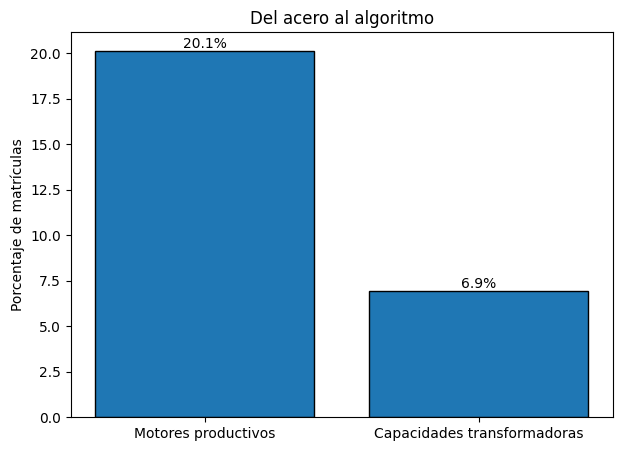

In [51]:
#Seleccionamos los dos bloques principales
tabla_acero_algoritmo = tabla_bloque.loc[
    ['Motores productivos', 'Capacidades transformadoras']
]

#Variables
categorias_adn = tabla_acero_algoritmo.index
h_adn = tabla_acero_algoritmo['Frecuencia relativa (%)']

#Gráfico
fig, ax = plt.subplots(figsize=(7,5))
barras_adn = ax.bar(
    categorias_adn,
    h_adn,
    edgecolor='black'
)

#Personalización
ax.set_title('Del acero al algoritmo')
ax.set_ylabel('Porcentaje de matrículas')
ax.bar_label(barras_adn, fmt='%.1f%%')

plt.show()


In [52]:
#Calculamos cuántas veces es mayor el bloque productivo
razon = (
    tabla_acero_algoritmo.loc[
        'Motores productivos',
        'Frecuencia absoluta'
    ]
    /
    tabla_acero_algoritmo.loc[
        'Capacidades transformadoras',
        'Frecuencia absoluta'
    ]
)

round(razon, 1)


np.float64(2.9)

### Interpretación

En la matrícula de pregrado de 2021 existen aproximadamente **2,9 matrículas vinculadas a motores productivos por cada matrícula vinculada a capacidades transformadoras**.

Este resultado describe la composición de la matrícula. No demuestra que exista un déficit de profesionales.


## 6.3 Frecuencia de las familias estratégicas


In [53]:
#Frecuencia absoluta por familia estratégica
cuenta_adn = d[
    d['ADN_BIOBIO'] != 'Otros campos'
].groupby('ADN_BIOBIO').size()

#Tabla de frecuencias
tabla_adn = pd.DataFrame({
    'Frecuencia absoluta': cuenta_adn,
    'Frecuencia relativa (%)': cuenta_adn/d.shape[0] * 100
})

tabla_adn = tabla_adn.sort_values(
    'Frecuencia absoluta',
    ascending=False
)

round(tabla_adn, 2)


,Frecuencia absoluta,Frecuencia relativa (%)
ADN_BIOBIO,,
Industria y manufactura,11221,11.10
Construccion e infraestructura,6916,6.84
Digital y TIC,3365,3.33
Automatizacion y robotica,2608,2.58
Logistica y puertos,1046,1.03
"Energia, sustentabilidad y biotecnologia",1027,1.02
Agroalimentario,863,0.85
Forestal y madera,171,0.17
Pesca y acuicultura,151,0.15


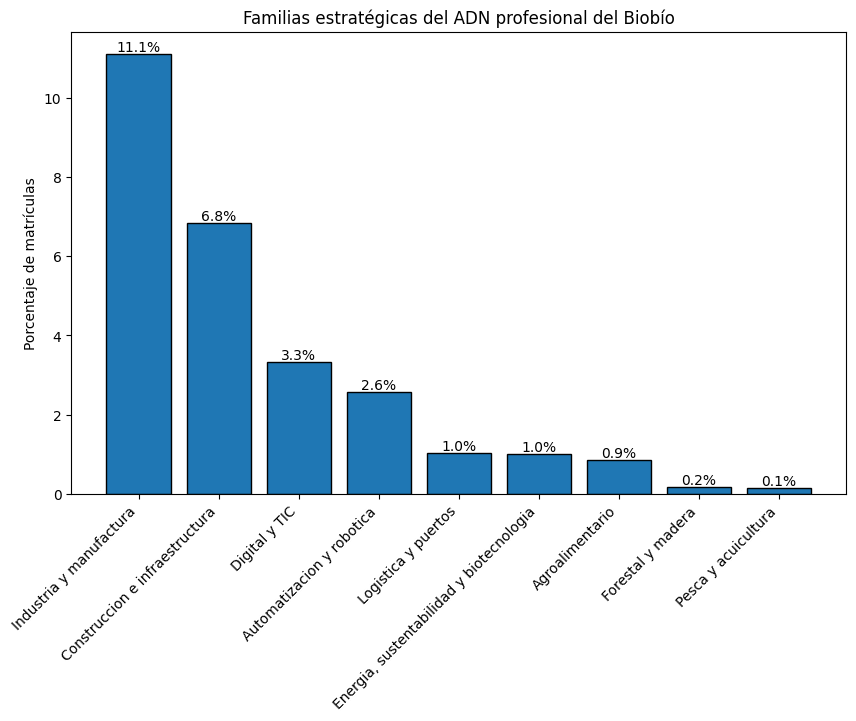

In [54]:
#Variables
categorias_familia = tabla_adn.index
h_familia = tabla_adn['Frecuencia relativa (%)']

#Gráfico
fig, ax = plt.subplots(figsize=(10,6))
barras_familia = ax.bar(
    categorias_familia,
    h_familia,
    edgecolor='black'
)

#Personalización
ax.set_title('Familias estratégicas del ADN profesional del Biobío')
ax.set_ylabel('Porcentaje de matrículas')
ax.bar_label(barras_familia, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')

plt.show()


**Interpretación:** Industria y manufactura es la familia estratégica de mayor peso (**11,10%**). Dentro de las capacidades transformadoras, Digital y TIC representa **3,33%**, Automatización y robótica **2,58%** y Energía/sustentabilidad/biotecnología **1,02%**.


## 6.4 Interpretación regional

Una explicación contextual posible es la **herencia productiva regional**: el Biobío posee una fuerte tradición industrial, manufacturera, forestal, logística y de construcción.

Al mismo tiempo, la agenda regional más reciente incorpora manufactura avanzada, tecnologías digitales e Industria 4.0.

Por eso la base 2021 puede entenderse como una **fotografía del punto de partida formativo**.

Si en el futuro la demanda por capacidades digitales y automatizadas creciera más rápido que la formación disponible, podrían aparecer dificultades de adopción tecnológica o una mayor dependencia de talento externo. Estas son **hipótesis de investigación**, no consecuencias demostradas por esta base.


# 7. Preguntas obligatorias del trabajo


## Pregunta 1
### ¿Hay áreas del conocimiento donde las carreras sean más caras? ¿Qué criterio diseñaron para responder?

**Criterio:** utilizaremos las **ofertas académicas únicas** y compararemos principalmente la **mediana del arancel** de cada área.

La mediana es adecuada porque no cambia tanto ante valores extremadamente altos o bajos.


In [55]:
#Agrupamos las ofertas por área
datos_p1 = ofertas.groupby(
    'AREA CONOCIMIENTO'
)['VALOR ARANCEL (PESOS)']

#Calculamos cantidad, media, mediana y percentiles
cantidad_p1 = datos_p1.size()
media_p1 = datos_p1.mean()
mediana_p1 = datos_p1.median()
p25_p1 = datos_p1.quantile(0.25)
p75_p1 = datos_p1.quantile(0.75)

#Creamos la tabla
tabla_p1 = pd.DataFrame({
    'Cantidad de ofertas': cantidad_p1,
    'Media': media_p1,
    'Mediana': mediana_p1,
    'Percentil 25': p25_p1,
    'Percentil 75': p75_p1
})

tabla_p1 = tabla_p1.sort_values(
    'Mediana',
    ascending=False
)

round(tabla_p1, 0)


,Cantidad de ofertas,Media,Mediana,Percentil 25,Percentil 75
AREA CONOCIMIENTO,,,,,
Derecho,18,3319065.0,3586000.0,2350000.0,4215000.0
Ciencias Basicas,31,3256166.0,3290000.0,2194500.0,4278045.0
Agropecuaria,18,3150941.0,2981500.0,1824250.0,4335000.0
Tecnologia,491,2301377.0,2122000.0,1730000.0,2276000.0
Salud,131,3044197.0,2080000.0,1781000.0,4203000.0
Humanidades,8,2115167.0,2006500.0,1717500.0,2579904.0
Arte y Arquitectura,35,2452345.0,1940000.0,1786000.0,2826500.0
Administracion y Comercio,251,2031019.0,1855000.0,1537000.0,2122000.0
Educacion,174,1952592.0,1722500.0,1399000.0,2654850.0


In [56]:
#Mediana global de las ofertas
mediana_global = ofertas[
    'VALOR ARANCEL (PESOS)'
].median()

print(f'Mediana global: ${mediana_global:.0f}')


Mediana global: $2030000


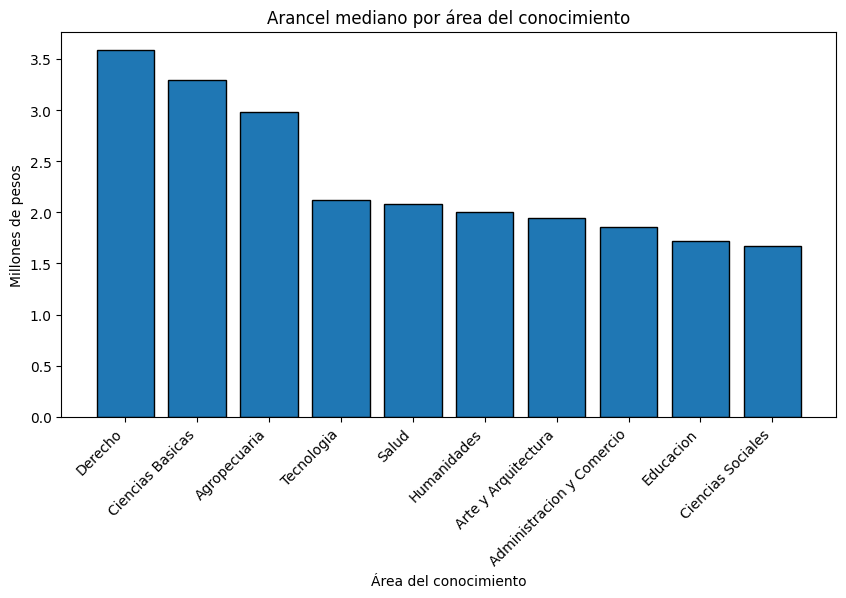

In [57]:
#Variables
categorias_p1 = tabla_p1.index
medianas_p1 = tabla_p1['Mediana']/1000000

#Gráfico
fig, ax = plt.subplots(figsize=(10,5))
barras_p1 = ax.bar(
    categorias_p1,
    medianas_p1,
    edgecolor='black'
)

#Personalización
ax.set_title('Arancel mediano por área del conocimiento')
ax.set_xlabel('Área del conocimiento')
ax.set_ylabel('Millones de pesos')
plt.xticks(rotation=45, ha='right')

plt.show()


### Respuesta

Sí. La mediana global de las 1.273 ofertas es **$2.030.000**.

Las mayores medianas corresponden a:

1. **Derecho:** $3.586.000.
2. **Ciencias Básicas:** $3.290.000.
3. **Agropecuaria:** $2.981.500.

Por lo tanto, existen áreas del conocimiento donde el arancel típico es claramente superior al valor global.


### Análisis complementario: área y tipo de institución

Usaremos una tabla bivariada como la trabajada con `crosstab()` en el Laboratorio 4.


In [58]:
tabla_p1_bivariada = pd.crosstab(
    ofertas['AREA CONOCIMIENTO'],
    ofertas['TIPO DE INSTITUCION'],
    ofertas['VALOR ARANCEL (PESOS)'],
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)

round(tabla_p1_bivariada, 0)


TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas,Total
AREA CONOCIMIENTO,,,,,,
Administracion y Comercio,1781338.0,1741044.0,NaN,2473294.0,2962050.0,2031019.0
Agropecuaria,1679333.0,1880000.0,NaN,4059110.0,4340417.0,3150941.0
Arte y Arquitectura,1769000.0,1850750.0,NaN,3848769.0,4637620.0,2452345.0
Ciencias Basicas,NaN,1878875.0,NaN,3758102.0,3495000.0,3256166.0
Ciencias Sociales,1353272.0,1419590.0,2327000.0,3691376.0,3069591.0,2129750.0
Derecho,NaN,1750000.0,2229000.0,4231569.0,3503926.0,3319065.0
Educacion,1364772.0,1439560.0,NaN,2673509.0,2490693.0,1952592.0
Humanidades,NaN,1005000.0,NaN,2763334.0,1929000.0,2115167.0
Salud,1735035.0,1740270.0,NaN,4419709.0,4246702.0,3044197.0


La tabla muestra que el arancel también cambia según el tipo de institución. Por eso una diferencia entre áreas no debe interpretarse como si el área fuera la única variable relacionada con el precio.


## Pregunta 2
### ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

Primero resumiremos la edad por tipo de institución. Luego compararemos los grupos de menor y mayor edad.


In [59]:
#Agrupamos por tipo de institución y calculamos cantidad, media y mediana
tabla_edad_institucion = d.groupby(
    'TIPO DE INSTITUCION'
)['EDAD'].agg(
    ['count', 'mean', 'median']
)

round(tabla_edad_institucion, 1)


,count,mean,median
TIPO DE INSTITUCION,,,
Centros de Formacion Tecnica,9455,25.7,23.0
Institutos Profesionales,26724,26.5,24.0
Universidades (* Carrera en Convenio),9,46.0,48.0
Universidades CRUCH,37997,22.8,22.0
Universidades Privadas,26908,24.0,23.0


Las universidades CRUCH presentan una edad mediana menor que los Institutos Profesionales y los Centros de Formación Técnica.


In [60]:
#Tabla bivariada con las frecuencias absolutas
tabla_edad_inst = pd.crosstab(
    d['RANGO EDAD'],
    d['TIPO DE INSTITUCION'],
    margins=True,
    margins_name='Total'
)

tabla_edad_inst


TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas,Total
RANGO EDAD,,,,,,
15 a 19,1847,3570,0,8554,4527,18498
20 a 24,4075,11633,0,21963,14724,52395
25 a 29,1467,4842,0,5409,4826,16544
30 a 34,894,2826,2,1173,1477,6372
35 a 39,496,1829,1,482,652,3460
40 y mas,676,2024,6,416,702,3824
Total,9455,26724,9,37997,26908,101093


Para interpretar mejor las diferencias, compararemos el grupo de **15 a 19 años** con el grupo de **40 años o más**.


In [61]:
#Grupo de 15 a 19 años
grupo_15_19 = d[
    d['RANGO EDAD'] == '15 a 19 '
]

#Frecuencia absoluta
frecuencia_15_19 = grupo_15_19.groupby(
    'TIPO DE INSTITUCION'
).size()

#Tabla de frecuencias
tabla_15_19 = pd.DataFrame({
    'Frecuencia absoluta': frecuencia_15_19,
    'Frecuencia relativa (%)':
        frecuencia_15_19/grupo_15_19.shape[0] * 100
})

round(tabla_15_19, 1)


,Frecuencia absoluta,Frecuencia relativa (%)
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,1847,10.0
Institutos Profesionales,3570,19.3
Universidades CRUCH,8554,46.2
Universidades Privadas,4527,24.5


In [62]:
#Grupo de 40 años o más
grupo_40 = d[
    d['RANGO EDAD'] == '40 y mas'
]

#Frecuencia absoluta
frecuencia_40 = grupo_40.groupby(
    'TIPO DE INSTITUCION'
).size()

#Tabla de frecuencias
tabla_40 = pd.DataFrame({
    'Frecuencia absoluta': frecuencia_40,
    'Frecuencia relativa (%)':
        frecuencia_40/grupo_40.shape[0] * 100
})

round(tabla_40, 1)


,Frecuencia absoluta,Frecuencia relativa (%)
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,676,17.7
Institutos Profesionales,2024,52.9
Universidades (* Carrera en Convenio),6,0.2
Universidades CRUCH,416,10.9
Universidades Privadas,702,18.4


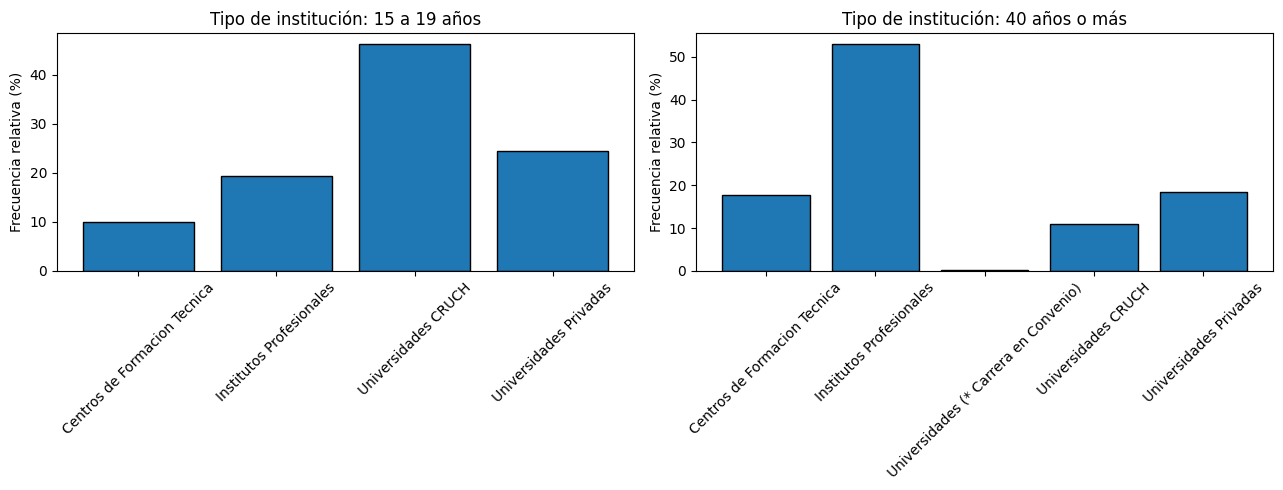

In [63]:
#Gráficos de los dos grupos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

barras_15 = ax1.bar(
    tabla_15_19.index,
    tabla_15_19['Frecuencia relativa (%)'],
    edgecolor='black'
)

barras_40 = ax2.bar(
    tabla_40.index,
    tabla_40['Frecuencia relativa (%)'],
    edgecolor='black'
)

ax1.set_title('Tipo de institución: 15 a 19 años')
ax2.set_title('Tipo de institución: 40 años o más')

ax1.set_ylabel('Frecuencia relativa (%)')
ax2.set_ylabel('Frecuencia relativa (%)')

ax1.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Respuesta

Se observan diferencias claras entre los grupos de edad:

- Entre **15 y 19 años**, las universidades CRUCH representan aproximadamente **46,24%** y los Institutos Profesionales **19,30%**.
- Entre quienes tienen **40 años o más**, los Institutos Profesionales representan aproximadamente **52,93%** y las universidades CRUCH **10,88%**.

Por lo tanto, la distribución del tipo de institución **cambia entre los distintos grupos de edad**. Esto es una asociación descriptiva; la base no permite afirmar que la edad sea la causa de la elección.


## Pregunta 3
### ¿Hay carreras cuyo arancel sea sustantivamente más caro que la mayoría?

**Criterio diseñado:** consideraremos como arancel sustantivamente alto a una oferta cuyo arancel esté **por sobre el percentil 90**.

Este criterio utiliza los percentiles trabajados en el curso: el percentil 90 deja aproximadamente al 90% de las ofertas en valores iguales o inferiores y permite estudiar el 10% superior.


In [64]:
#Valor mínimo del 10% más alto
p90_ofertas = ofertas[
    'VALOR ARANCEL (PESOS)'
].quantile(0.90)

#Valor máximo
maximo_ofertas = ofertas[
    'VALOR ARANCEL (PESOS)'
].max()

print(f'Percentil 90: ${p90_ofertas:.0f}')
print(f'Máximo: ${maximo_ofertas}')


Percentil 90: $4106400
Máximo: $8783670


Las ofertas ubicadas en el 10% superior se encuentran aproximadamente entre **$4.106.400** y **$8.783.670**.


In [65]:
#Filtramos las ofertas que superan el percentil 90
altas = ofertas[
    ofertas['VALOR ARANCEL (PESOS)'] > p90_ofertas
].copy()

#Cantidad y porcentaje
cantidad_altas = altas.shape[0]
porcentaje_altas = cantidad_altas/ofertas.shape[0] * 100

print(f'Ofertas sobre P90: {cantidad_altas}')
print(f'Porcentaje: {porcentaje_altas:.1f}%')


Ofertas sobre P90: 128
Porcentaje: 10.1%


### ¿Qué variables de la base nos ayudan a comprender este grupo?

Revisaremos tipo de institución, área del conocimiento, provincia y duración de la carrera.


In [66]:
#Frecuencia por tipo de institución
altas.groupby(
    'TIPO DE INSTITUCION'
).size().sort_values(ascending=False)


TIPO DE INSTITUCION
Universidades CRUCH       73
Universidades Privadas    55
dtype: int64

In [67]:
#Frecuencia por área del conocimiento
altas.groupby(
    'AREA CONOCIMIENTO'
).size().sort_values(ascending=False)


AREA CONOCIMIENTO
Salud                        38
Tecnologia                   38
Ciencias Basicas             13
Administracion y Comercio    10
Ciencias Sociales            10
Agropecuaria                  7
Derecho                       7
Arte y Arquitectura           5
dtype: int64

In [68]:
#Frecuencia por provincia
altas.groupby(
    'PROVINCIA SEDE'
).size().sort_values(ascending=False)


PROVINCIA SEDE
Concepcion    123
Biobio          5
dtype: int64

In [69]:
#Comparamos la duración mediana de las ofertas altas con el resto
duracion_altas = altas[
    'DURACION TOTAL CARRERA (SEMESTRES)'
].median()

resto = ofertas[
    ofertas['VALOR ARANCEL (PESOS)'] <= p90_ofertas
]

duracion_resto = resto[
    'DURACION TOTAL CARRERA (SEMESTRES)'
].median()

print(f'Duración mediana ofertas altas: {duracion_altas} semestres')
print(f'Duración mediana resto: {duracion_resto} semestres')


Duración mediana ofertas altas: 10.0 semestres
Duración mediana resto: 5.0 semestres


In [70]:
#Cantidad de ofertas y arancel mediano por carrera
ranking_carreras = ofertas.groupby(
    'NOMBRE CARRERA'
)['VALOR ARANCEL (PESOS)'].agg(
    ['count', 'median']
)

ranking_carreras.columns = [
    'Cantidad de ofertas',
    'Arancel mediano'
]

#Consideramos carreras con al menos 3 ofertas
ranking_carreras = ranking_carreras[
    ranking_carreras['Cantidad de ofertas'] >= 3
]

ranking_carreras = ranking_carreras.sort_values(
    'Arancel mediano',
    ascending=False
).head(10)

ranking_carreras


,Cantidad de ofertas,Arancel mediano
NOMBRE CARRERA,,
MEDICINA,3,7490000.0
ODONTOLOGIA,5,7290000.0
INGENIERIA CIVIL QUIMICA,3,4804479.0
TECNOLOGIA MEDICA,4,4771050.0
INGENIERIA CIVIL INFORMATICA,3,4745935.0
MEDICINA VETERINARIA,6,4320000.0
KINESIOLOGIA,9,4224000.0
ARQUITECTURA,6,4214450.0
INGENIERIA CIVIL ELECTRICA,4,4202239.5


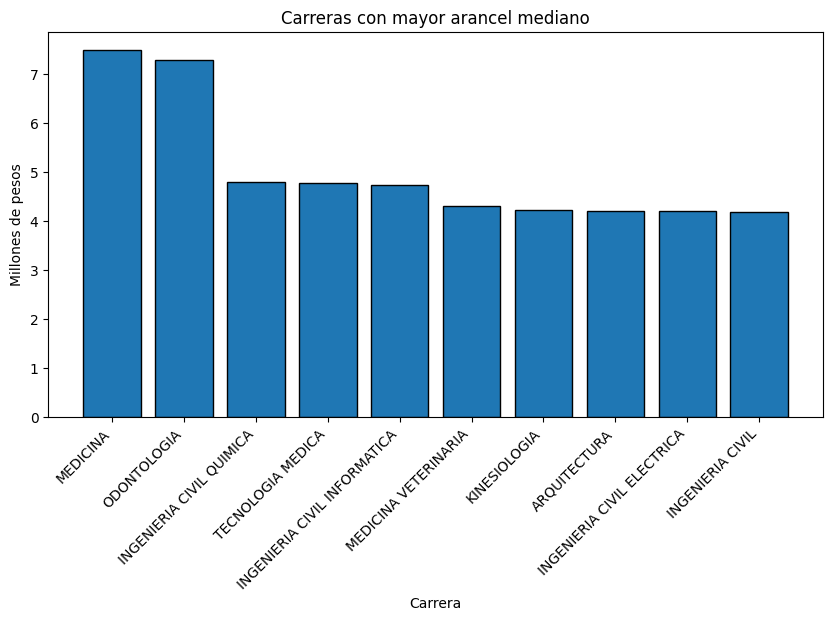

In [71]:
#Gráfico de las 10 carreras con mayor arancel mediano
categorias_p3 = ranking_carreras.index
medianas_p3 = ranking_carreras[
    'Arancel mediano'
]/1000000

fig, ax = plt.subplots(figsize=(10,5))

barras_p3 = ax.bar(
    categorias_p3,
    medianas_p3,
    edgecolor='black'
)

ax.set_title('Carreras con mayor arancel mediano')
ax.set_xlabel('Carrera')
ax.set_ylabel('Millones de pesos')
plt.xticks(rotation=45, ha='right')

plt.show()


### Respuesta

Sí. El **percentil 90** de las 1.273 ofertas es aproximadamente **$4.106.400**.

Superan ese valor **128 ofertas**, equivalentes a aproximadamente **10,1%** del total.

Entre esas ofertas:

- **73** corresponden a universidades CRUCH y **55** a universidades privadas.
- **123** se encuentran en Concepción y **5** en Biobío.
- Salud y Tecnología concentran **38 ofertas cada una**.
- La duración mediana es de **10 semestres**, frente a **5 semestres** en el resto de las ofertas.

Entre las carreras con mayor arancel mediano aparecen **Medicina** y **Odontología**.

Estos resultados permiten describir asociaciones entre arancel, institución, área, provincia y duración. La base no demuestra que alguna de estas variables sea la causa del precio.


# 8. Conclusiones generales

## 8.1 Sobre las herramientas estadísticas

El análisis utilizó los contenidos trabajados durante el curso:

- manejo básico de DataFrames con Pandas;
- filtros y creación de columnas;
- población, muestra y clasificación de variables;
- tablas de frecuencias absolutas, relativas y acumuladas;
- variables agrupadas con `pd.cut()`;
- gráficos circulares, barras, histogramas y dispersión;
- media, mediana y moda;
- percentiles;
- `describe()`;
- análisis agrupados con `groupby()` y `agg()`;
- tablas bivariadas con `crosstab()`;
- rango, desviación estándar y coeficiente de variación.

## 8.2 Sobre “Del acero al algoritmo”

En la matrícula de pregrado de 2021:

- **20,15%** se clasifica en motores productivos.
- **6,92%** se clasifica en capacidades transformadoras.

Esto equivale aproximadamente a **2,9 matrículas de motores productivos por cada matrícula transformadora**.

La fotografía de 2021 muestra, por lo tanto, una base formativa vinculada a actividades productivas considerablemente mayor que la vinculada a digitalización, automatización y sustentabilidad.


# 9. Limitaciones

- La base corresponde únicamente a 2021.
- La clasificación “Acero/Algoritmo” fue creada para este trabajo.
- Una carrera puede contribuir a más de un sector, aunque aquí se asigna a una sola familia para evitar doble conteo.
- Los aranceles corresponden a los valores registrados en la base.
- La base no contiene vacantes, salarios de egresados, productividad ni demanda laboral.
- Los resultados son descriptivos y no permiten demostrar causalidad.
